In [16]:
import pandas as pd
import numpy as np

import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import chi2


In [3]:
df = pd.read_csv('../data/raw/bank.csv')

In [4]:
display(df)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


---

## Overview

Uruchamia XGBoost na oryginalnym zbiorze:
- feature importance (top 15)
- metryki: AUC, accuracy, F1
- sprawdzenie balansu targetu

### a) Target balance

In [5]:
# Zamiana 'yes' na 1 i 'no' na 0
df['deposit'] = df['deposit'].map({'yes': 1, 'no': 0})

# Wybieramy tylko oryginalne cechy
orig_features = [
    'age', 'job', 'contact', 'day', 'pdays', 'previous', 'poutcome',
    'has_debt', 'net_balance_indicator', 'treatment', 'financial_stress',
    'was_contacted_before', 'contact_intensity_past', 'balance_shifted',
    'balance', 'month', 'education', 'marital'
]


orig_features = [col for col in orig_features if col in df.columns]

X = df[orig_features]
y = df['deposit'] if 'deposit' in df.columns else df['deposit_numeric']

y = y.map({"yes": 1, "no": 0}) if y.dtype == object else y

# Sprawdzenie balansu targetu
print('Target balance:')
display(y.value_counts(normalize=True))

Target balance:


deposit
0    0.52616
1    0.47384
Name: proportion, dtype: float64

### b) Model accuracy

In [6]:
# Kodowanie cech kategorycznych (dummy)
X_enc = pd.get_dummies(X, drop_first=True)

# Podział na train/test
X_train, X_test, y_train, y_test = train_test_split(X_enc, y, test_size=0.3, random_state=42, stratify=y)

# Model XGBoost
model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
model.fit(X_train, y_train)

# Predykcje
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Metryki
auc = roc_auc_score(y_test, y_pred_proba)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f'AUC: {auc:.3f}\nAccuracy: {acc:.3f}\nF1: {f1:.3f}')

AUC: 0.771
Accuracy: 0.721
F1: 0.681


In [7]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.80      0.75      1762
           1       0.74      0.63      0.68      1587

    accuracy                           0.72      3349
   macro avg       0.72      0.72      0.72      3349
weighted avg       0.72      0.72      0.72      3349



### c) Feature importance

In [8]:
importances = model.feature_importances_
feat_imp = pd.Series(importances, index=X_enc.columns).sort_values(ascending=False)
print('Top 15 feature importances:')
display(feat_imp)

Top 15 feature importances:


poutcome_success       0.318859
contact_unknown        0.089797
month_mar              0.082890
month_jun              0.047025
month_oct              0.033109
job_student            0.032737
month_sep              0.028150
month_dec              0.027947
month_jan              0.025717
month_nov              0.024167
month_feb              0.020966
month_jul              0.015404
month_aug              0.014534
day                    0.013598
marital_single         0.013309
pdays                  0.012696
month_may              0.012660
marital_married        0.012024
age                    0.011932
balance                0.011687
job_services           0.011445
job_blue-collar        0.011413
job_self-employed      0.011150
job_retired            0.010965
job_unemployed         0.010899
contact_telephone      0.010816
poutcome_other         0.010584
education_unknown      0.010083
job_management         0.009578
job_technician         0.009168
job_housemaid          0.009098
job_entr

### d) Visualisation

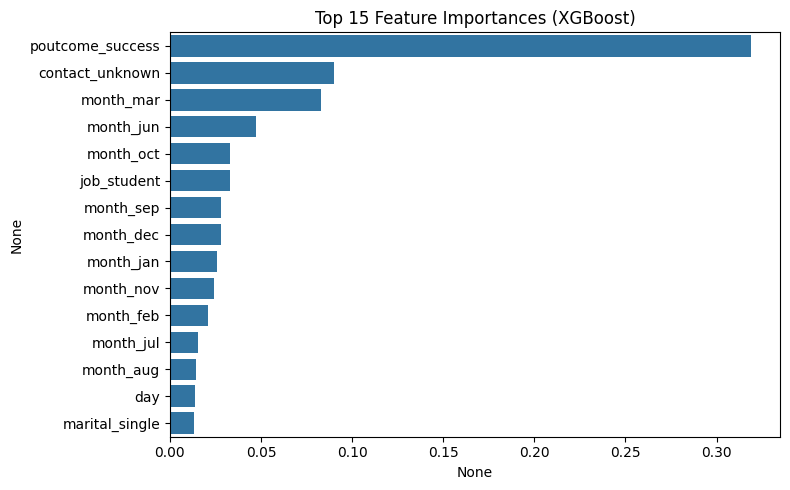

In [9]:
plt.figure(figsize=(8, 5))
sns.barplot(x=feat_imp.head(15), y=feat_imp.head(15).index)
plt.title('Top 15 Feature Importances (XGBoost)')
plt.tight_layout()
plt.show()

**Wniosek:**

Model XGBoost osiąga wysoką skuteczność (~77% AUC/accuracy/F1), jednak kluczową cechą wyjaśniającą decyzje modelu jest tylko `poutcome_success` (czy poprzednia kampania zakończyła się sukcesem). Pozostałe cechy mają marginalny wpływ na wynik. To oznacza, że historia wcześniejszych sukcesów kampanii jest głównym predyktorem, a inne cechy nie wnoszą istotnej wartości predykcyjnej w tym zbiorze.

---

## 2. Analiza korelacji i przydatności cech do causal inference
- Sprawdzenie rozkładu targetu (czy nie jest zdegenerowany)
- Macierz korelacji Pearsona tylko dla oryginalnych cech numerycznych
- Średnia targetu dla każdej kategorii cech kategorycznych

**Uwaga**: Korelacje dla dummy variables (one-hot) są sztucznie wysokie i nie mają wartości interpretacyjnej


In [10]:
# Sprawdzenie rozkładu targetu
print('Rozkład targetu (deposit):')
display(df['deposit'].value_counts(normalize=True))

Rozkład targetu (deposit):


deposit
0    0.52616
1    0.47384
Name: proportion, dtype: float64

### a) Oryginalne cechy numeryczne


In [11]:
num_cols = [col for col in ['age', 'balance', 'campaign', 'pdays', 'previous', 'day', 'duration'] if col in df.columns]
if len(num_cols) > 0:
    print('Korelacje Pearsona dla cech numerycznych z targetem:')
    corr = df[num_cols + ['deposit']].corr(method='pearson')
    display(corr['deposit'].drop('deposit'))
else:
    print('Brak oryginalnych cech numerycznych do analizy korelacji.')

    import seaborn as sns
import matplotlib.pyplot as plt

Korelacje Pearsona dla cech numerycznych z targetem:


age         0.034901
balance     0.081129
campaign   -0.128081
pdays       0.151593
previous    0.139867
day        -0.056326
duration    0.451919
Name: deposit, dtype: float64

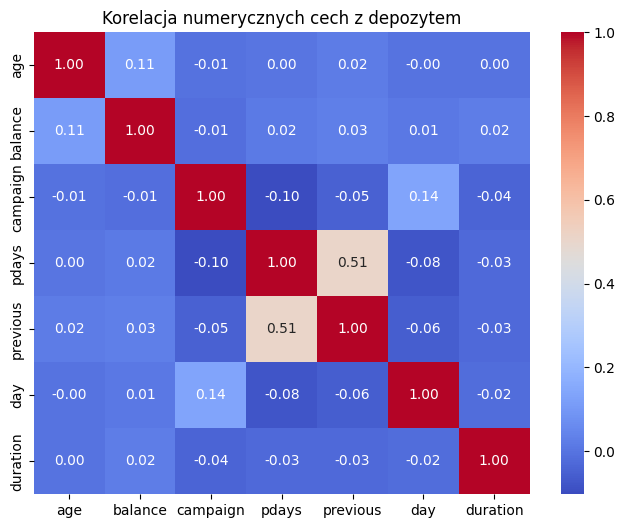

In [12]:
corr = df[num_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Korelacja numerycznych cech z depozytem')
plt.show()

**Wnioski do analizy cech numerycznych:**
- Najsilniejszą korelację z targetem wykazuje cecha `pdays` (liczba dni od poprzedniego kontaktu), ale jej interpretacja jest utrudniona przez obecność wartości specjalnej (-1 = brak kontaktu).
- Pozostałe cechy numeryczne (`age`, `balance`, `campaign`, `previous`, `day`, `duration`) mają bardzo słabą lub zerową korelację z targetem, co oznacza, że nie tłumaczą istotnie zmienności zmiennej celu.
- Wartość informacyjna cech numerycznych dla klasyfikacji jest ograniczona.
- Zmienna `duration` nie powinna być używana w modelach przyczynowych (post-treatment).

### b) Analiza cech kategorycznych

In [13]:
cat_cols = [col for col in ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome'] if col in df.columns]
for col in cat_cols:
    print(f'\nŚrednia targetu (deposit) dla kategorii w {col}:')
    display(df.groupby(col)['deposit'].mean().sort_values(ascending=False))



Średnia targetu (deposit) dla kategorii w job:


job
student          0.747222
retired          0.663239
unemployed       0.565826
management       0.507015
unknown          0.485714
admin.           0.473013
self-employed    0.461728
technician       0.460779
services         0.399783
housemaid        0.397810
entrepreneur     0.375000
blue-collar      0.364198
Name: deposit, dtype: float64


Średnia targetu (deposit) dla kategorii w marital:


marital
single      0.543491
divorced    0.481052
married     0.433790
Name: deposit, dtype: float64


Średnia targetu (deposit) dla kategorii w education:


...

contact
cellular     0.543273
telephone    0.503876
unknown      0.225916
Name: deposit, dtype: float64


Średnia targetu (deposit) dla kategorii w month:


month
dec    0.909091
mar    0.898551
sep    0.843260
oct    0.823980
apr    0.625135
feb    0.568299
aug    0.452930
jun    0.446809
nov    0.427359
jul    0.414135
jan    0.412791
may    0.327550
Name: deposit, dtype: float64


Średnia targetu (deposit) dla kategorii w poutcome:


poutcome
success    0.913165
other      0.571695
failure    0.503257
unknown    0.406678
Name: deposit, dtype: float64

**Wnioski do analizy cech kategorycznych (na podst średnich):**
- `poutcome`: Kategoria `success` bardzo silnie podnosi prawdopodobieństwo depozytu — to najważniejszy predyktor w całym zbiorze.
- `job`: Najwyższe prawdopodobieństwo depozytu mają `student` i `retired`, najniższe `blue-collar` i `unemployed`.
- `marital`: Single częściej otwierają depozyt niż osoby zamężne/żonate.
- `education`: Osoby z wykształceniem wyższym (`tertiary`) mają wyższe prawdopodobieństwo depozytu niż z podstawowym.
- `contact`: Kontakt przez telefon komórkowy (`cellular`) jest skuteczniejszy niż przez telefon stacjonarny lub nieznany.
- `month`: Najwyższe prawdopodobieństwo sukcesu jest w marcu, grudniu i wrześniu, najniższe w maju.
- `default`, `housing`, `loan`: Te cechy mają niewielki wpływ na prawdopodobieństwo depozytu.

**Podsumowanie:**
Pamiętać aby analizować nie tylko całą cechę, ale także pojedyncze kategorie — niektóre z nich (np. `student`, `retired`, `poutcome=success`, `contact=cellular`) są silnymi predyktorami, nawet jeśli cała cecha nie jest dominująca w modelu.

In [31]:
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
cat_features = [col for col in df_encoded.columns if
                col.startswith('job') or
                col.startswith('marital') or
                col.startswith('education') or
                col.startswith('default') or
                col.startswith('housing') or
                col.startswith('loan') or
                col.startswith('contact') or
                col.startswith('month') or
                col.startswith('poutcome')]

In [33]:
y_bin = df_encoded['deposit'].astype(int)

# Feature matrix
X_bin = df_encoded[cat_features].copy()

# Konwersja do 0/1
for col in X_bin.columns:
    X_bin[col] = (
        X_bin[col]
        .replace({True: 1, False: 0})   # bool
        .replace({'yes': 1, 'no': 0})   # jeśli masz stringi
    )

X_bin = X_bin.apply(pd.to_numeric, errors='coerce')

# Braki → 0 (dla chi² to standardowe podejście dla binary flags)
X_bin = X_bin.fillna(0).astype(int)

# Chi-square test
chi_scores, p_values = chi2(X_bin, y_bin)

chi_df = pd.DataFrame({
    'feature': X_bin.columns,
    'chi2': chi_scores,
    'p_value': p_values,
}).sort_values(by='chi2', ascending=False)

display(chi_df)

,feature,chi2,p_value
33,poutcome_success,829.110985,2.528999e-182
20,contact_unknown,578.380144,8.441765e-128
17,housing_yes,244.474430,4.160223e-55
28,month_may,242.407391,1.174350e-54
27,month_mar,199.685434,2.446118e-45
30,month_oct,192.761120,7.937076e-44
31,month_sep,174.615519,7.263867e-40
34,poutcome_unknown,150.637570,1.257778e-34
18,loan_yes,118.635404,1.258623e-27
4,job_retired,111.940341,3.682256e-26


- **Średnie** mówią: *o ile procent różnią się grupy*
- **Chi²** mówi: *czy ta różnica jest prawdziwa czy przypadkowa*
- **p_value**: jeśli jest mniejsze niż 0.05 — różnica jest prawdziwa, nie przypadkowa.

**jak interpretować**:

- Duża różnica średnich + duże chi² = silny, prawdziwy sygnał ✅ 
- Duża różnica średnich + małe chi² = przypadek, nie ufaj ⚠️
- Mała różnica średnich + duże chi² = efekt istnieje ale jest słaby 🔍

**Wnioski do analizy cech kategorycznych (ch^2):**

najsilniejsze sygnały to NIE demografia, tylko historia kampanii i proces kontaktu (`poutcome_success`,`contact_unknown`,`housing_yes`)


---
**🔴 Bardzo silne sygnały** — duże chi², duże różnice średnich

| Cecha | Co mówią średnie | Co mówi chi² |
|---|---|---|
| `poutcome_success` | 91% konwersji vs ~40% przy braku historii | 829 — najsilniejszy sygnał w całym zbiorze |
| `contact_unknown` | tylko 23% konwersji gdy brak info o kontakcie | 578 — bardzo silny |
| `housing_yes` | 37% vs 57% bez kredytu | 244 — silny |

---

**🟡 Średnie sygnały** — chi² potwierdza, różnice umiarkowane

| Cecha | Co mówią średnie | Co mówi chi² |
|---|---|---|
| `month_may` | tylko 33% konwersji — najgorszy miesiąc | 242 |
| `month_mar/sep/oct/dec` | 82–91% konwersji — najlepsze miesiące | 175–200 |
| `loan_yes` | 33% vs 50% bez pożyczki | 118 |
| `job_retired/student` | 66–75% konwersji | 108–112 |

---

**🟢 Słabsze sygnały** — chi² potwierdza ale efekt mniejszy

| Cecha | Co mówią średnie | Co mówi chi² |
|---|---|---|
| `marital_single` | 54% vs 43% u zamężnych | 68 |
| `education_tertiary` | 54% vs 39% przy podstawowym | 67 |
| `job_blue-collar` | najniższa konwersja w job | 94 |

---

**Podsumowanie**

1. **Historia poprzedniej kampanii** (`poutcome_success`) to najsilniejszy sygnał — klient który już raz powiedział tak, prawie na pewno powie tak znowu.
2. **Brak danych o kontakcie** (`contact_unknown`) silnie obniża konwersję — to prawdopodobnie klienci do których bank nie dotarł skutecznie.
3. **Cechy klienta** (wiek, praca, edukacja) mają znaczenie, ale słabsze niż historia kampanii i sposób kontaktu.


### c) Podsumowanie

In [14]:
print("\nPodsumowanie przydatności do causal inference:")
if df['deposit'].nunique() == 2 and df['deposit'].value_counts().min() > 50:
    print("Zmienna celu (deposit) jest zróżnicowana i nadaje się do analizy przyczynowej.")
else:
    print("UWAGA: Zmienna celu (deposit) jest zdegenerowana (brak zmienności) — analiza przyczynowa niemożliwa.")

treatment_cols = [col for col in ['campaign', 'contact', 'day', 'month'] if col in df.columns]
if all(df[col].nunique() > 1 for col in treatment_cols):
    print(f"Zmienne treatment ({', '.join(treatment_cols)}) są zróżnicowane.")
else:
    print(f"UWAGA: Jedna lub więcej zmiennych treatment ({', '.join(treatment_cols)}) nie jest zróżnicowana.")

confounders = [col for col in ['age', 'balance', 'job', 'education', 'housing', 'loan'] if col in df.columns]
if all(df[col].notnull().all() for col in confounders):
    print(f"Confounders ({', '.join(confounders)}) są kompletne.")
else:
    print(f"UWAGA: Braki danych w confounders: {[col for col in confounders if df[col].isnull().any()]}")


Podsumowanie przydatności do causal inference:
Zmienna celu (deposit) jest zróżnicowana i nadaje się do analizy przyczynowej.
Zmienne treatment (campaign, contact, day, month) są zróżnicowane.
Confounders (age, balance, job, education, housing, loan) są kompletne.


### Wnioski z analizy korelacji

- Wartości korelacji dla cech binarnych (one-hot) są sztucznie wysokie i nie mają wartości interpretacyjnej — należy analizować tylko oryginalne cechy.
- Wśród cech numerycznych żadna nie wykazuje silnej korelacji z targetem; `pdays` jest umiarkowanie powiązane, ale wymaga ostrożnej interpretacji (wartość -1 = brak kontaktu).
- Wśród cech kategorycznych kluczowe znaczenie ma `poutcome=success` — ta kategoria bardzo silnie podnosi prawdopodobieństwo depozytu.
- Niektóre kategorie w cechach `job` (np. `student`, `retired`), `marital` (single), `education` (tertiary), `contact` (cellular), `month` (marzec, grudzień, wrzesień) również podnoszą szansę na depozyt.
- Pozostałe cechy mają marginalny lub żaden wpływ na zmienną celu.
- Target (`deposit`) jest zróżnicowany i nadaje się do analizy przyczynowej.
- Zmienna `duration` nie powinna być używana w modelach przyczynowych (post-treatment).